# CPS 535 — Introduction to Large Language Models
## Week 2: Tokens and Embeddings

Last week we covered the history of language AI and refreshed the neural network mechanics that everything else in this course builds on. This week we open up the first stage of every LLM pipeline: turning raw text into numbers a model can actually work with.

That happens in two steps. **Tokenization** breaks text into pieces (tokens). **Embedding** turns each token into a vector that captures something about its meaning. Every LLM you will touch this semester, GPT, BERT, Llama, whatever comes next, starts here.

**This notebook covers:**
1. What tokens and embeddings are, and how they fit together
2. Tokenization schemes: word, subword, character, byte
3. Comparing real tokenizers (BERT vs. GPT-style) on tricky text
4. Building a byte-pair encoding (BPE) tokenizer from scratch
5. The Word2Vec algorithm: sliding windows, negative sampling, and doing one full update by hand
6. The same idea, implemented in PyTorch
7. Word2Vec at scale with `gensim`
8. Where this goes next
9. Exercise: embeddings for recommendation systems

As with Week 1, this notebook is written to be read as a standalone reference, not just a script to run. Read the text, run the cells, and poke at the code.

## 1. Tokens and Embeddings: the big picture

An LLM cannot read text. It reads numbers. So before any prompt reaches the model, it goes through a pipeline:

```
"Have the bards who preceded..."
        |
        v   tokenizer.encode()
   [Have, the, bards, who, preceded, ...]     <- tokens
        |
        v   look up each token's ID
   [6975, 278, 278, 3363, 1058, ...]           <- token IDs
        |
        v   embedding layer
   [[0.12, -0.4, ...], [0.05, 0.9, ...], ...]  <- embedding vectors
        |
        v
    language model
```

Two ideas worth pinning down before we go further:

- **Tokenization** is a fixed, deterministic algorithm decided before training. It does not "understand" anything, it just applies splitting rules over and over.
- **Embeddings** are learned. The vector for a token starts out random and is adjusted during training so tokens with similar meaning or usage end up with similar vectors.

Everything below is about how these two steps actually work, and why the specific design choices (subword tokens, negative sampling, etc.) exist.

In [ ]:
# A tiny preview: same sentence, three different tokenizers will
# cut it into different pieces. We'll build up to this properly below.
sentence = "Have the bards who preceded me left any theme unsung?"
print("Word-level split:", sentence.split())
print("Character-level split:", list(sentence.replace(' ', '_')))

## 2. Tokenization schemes

There isn't one correct way to cut text into tokens. Every scheme trades off vocabulary size, sequence length, and how gracefully it handles words the tokenizer has never seen. Slides covered four schemes; let's implement each one directly so the trade-offs are concrete instead of abstract.

In [ ]:
text = "Have the bards who preceded me left any theme unsung?"

# --- Word tokens ---
def word_tokenize(text):
    return text.replace('?', ' ?').split()

# --- Character tokens ---
def char_tokenize(text):
    return list(text)

# --- Byte tokens ---
def byte_tokenize(text):
    return list(text.encode("utf-8"))

print("Word tokens     :", word_tokenize(text))
print("Character tokens:", char_tokenize(text)[:15], "...")
print("Byte tokens      :", byte_tokenize(text)[:15], "...")

Look at what happens to each scheme's vocabulary and sequence length:

| Scheme | Vocabulary size | Sequence length | Handles unseen words? |
|---|---|---|---|
| Word | Huge (every word form is its own entry) | Short | No, unseen word = unknown token |
| Character | Tiny (~100 symbols) | Very long | Yes, but "modeling becomes difficult" (the model has to learn spelling before it can learn meaning) |
| Byte | Smallest possible (256 values) | Longest | Yes, always, any Unicode text reduces to bytes |
| Subword | Medium, tunable | Medium | Yes, unseen words fall back to smaller known pieces |

Word tokenizers also waste vocabulary slots on near-duplicates: `apology`, `apologize`, `apologetic`, and `apologist` would each get their own entry, even though they share a root. Subword tokenization is the compromise every modern LLM actually uses: common words stay whole, rare or unseen words get broken into smaller, still-meaningful pieces.

Let's see how that compromise is actually built.

## 3. Building a subword tokenizer from scratch (BPE)

Byte-Pair Encoding (BPE) is the algorithm behind GPT-style tokenizers. The idea is simple and greedy:

1. Start with every word split into individual characters.
2. Count every adjacent pair of symbols across the whole corpus.
3. Merge the most frequent pair into a single new symbol.
4. Repeat for a fixed number of merges.

Common substrings (like `-er` or `-est`) get merged early because they show up constantly. Rare substrings never get merged, so they stay as small, granular pieces. Nothing here is learned by gradient descent, it's pure frequency counting.

In [ ]:
from collections import Counter, defaultdict

def get_word_freqs(corpus):
    '''Split each word into characters, with </w> marking word end.'''
    freqs = Counter()
    for word in corpus.split():
        freqs[' '.join(list(word)) + ' </w>'] += 1
    return freqs

def get_pair_counts(word_freqs):
    '''Count every adjacent symbol pair, weighted by word frequency.'''
    pairs = defaultdict(int)
    for word, freq in word_freqs.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i + 1])] += freq
    return pairs

def merge_pair(pair, word_freqs):
    '''Replace every occurrence of the pair with a single merged symbol.'''
    bigram = ' '.join(pair)
    replacement = ''.join(pair)
    return {word.replace(bigram, replacement): freq for word, freq in word_freqs.items()}

def train_bpe(corpus, num_merges):
    word_freqs = get_word_freqs(corpus)
    merges = []
    for _ in range(num_merges):
        pairs = get_pair_counts(word_freqs)
        if not pairs:
            break
        best_pair = max(pairs, key=pairs.get)
        word_freqs = merge_pair(best_pair, word_freqs)
        merges.append(best_pair)
    return merges, word_freqs

In [ ]:
corpus = "low lower lowest new newer newest wide wider widest"
merges, final_vocab = train_bpe(corpus, num_merges=8)

for i, pair in enumerate(merges):
    print(f"merge {i+1}: {pair} -> '{''.join(pair)}'")

print("\nFinal subword segmentation:")
for word, freq in final_vocab.items():
    print(f"  {word}")

Notice what got learned automatically, without anyone telling the algorithm English morphology: `e` + `r` merged into `er`, `s` + `t` into `st`, and eventually `st` + `</w>` into a word-final `st`. The algorithm rediscovered the suffixes `-er` and `-est` purely from co-occurrence counts. This is exactly the mechanism behind slides 10-11 (subword tokens breaking unseen words into smaller, still-meaningful pieces).

Real tokenizers (GPT-2's, for example) run this same algorithm on billions of words with tens of thousands of merges. Let's look at the real thing next.

## 4. Comparing real tokenizers

Now let's load actual tokenizers and run the exact kind of stress test from the slides: capitalization, emoji, non-English text, code syntax, and numbers. This is where tokenizer design choices become very visible.

> **Note:** this cell downloads tokenizer files from Hugging Face and OpenAI the first time you run it, so you'll need an internet connection. If you're on a restricted network (e.g. a locked-down lab machine), run this at home or on Colab.

In [ ]:
from transformers import AutoTokenizer
import tiktoken

test_strings = [
    "English and CAPITALIZATION",
    "🎵🐦",  # emoji
    "show_tokens False None elif == >= else: two tabs:\"  \" Three tabs: \"   \"",
    "12.0*50=600",
]

bert_tok = AutoTokenizer.from_pretrained("bert-base-uncased")
gpt2_tok = AutoTokenizer.from_pretrained("gpt2")
gpt4_tok = tiktoken.get_encoding("cl100k_base")  # same family used by GPT-3.5/4

def show_tokens(text, tokenizer, is_tiktoken=False):
    if is_tiktoken:
        ids = tokenizer.encode(text)
        pieces = [tokenizer.decode([i]) for i in ids]
    else:
        pieces = tokenizer.tokenize(text)
    return pieces

for s in test_strings:
    print(f"\nInput: {s!r}")
    print("  BERT  :", show_tokens(s, bert_tok))
    print("  GPT-2 :", show_tokens(s, gpt2_tok))
    print("  GPT-4 :", show_tokens(s, gpt4_tok, is_tiktoken=True))

A few things worth noticing once you run this:

- **BERT lowercases everything** (`bert-base-uncased`) and splits unknown pieces with a `##` prefix to mark "this continues the previous token." GPT-style tokenizers preserve case and use a leading space marker instead.
- **Whitespace handling differs a lot.** GPT-style byte-level BPE tokenizers encode tabs and multiple spaces as their own tokens, which is exactly why they're a strong choice for tokenizing code. BERT's tokenizer normalizes whitespace away, since it wasn't designed with code in mind.
- **Emoji and non-English text** typically survive intact in GPT-4's tokenizer (bigger vocabulary, byte-level fallback for anything unseen) but may get shredded into byte fragments or an `[UNK]` token in BERT, which had a smaller, English-heavy training vocabulary.
- **Numbers get split inconsistently.** `600` might be one token, or `6` + `00`, depending on what digit groupings were common in the tokenizer's training data. This is a well-known reason LLMs are shaky at arithmetic: the model never sees numbers as numbers, it sees arbitrary digit chunks.

This directly explains why vocabulary size matters. Run the cell below to see it as plain numbers.

In [ ]:
print(f"BERT vocab size : {bert_tok.vocab_size:,}")
print(f"GPT-2 vocab size: {gpt2_tok.vocab_size:,}")
print(f"GPT-4 vocab size: {gpt4_tok.n_vocab:,}")

Bigger vocabularies mean fewer tokens per sentence (shorter sequences, cheaper to process) but a larger embedding table to learn. This is a real design decision every LLM team makes, not a solved problem.

## 5. The Word2Vec algorithm

Tokenization gives us discrete symbols. Embeddings turn those symbols into vectors where distance and direction mean something. Word2Vec (Mikolov et al., 2013) is the classic algorithm for learning these vectors, and it's the cleanest way to understand embeddings in general, including the ones inside modern LLMs.

**The core trick:** turn "learn what a word means" into a supervised classification problem that needs no manual labels.

1. **Slide a window** across the training text. With window size 2, each center word is paired with its two neighbors on each side.
2. **Generate training pairs**: (center word, neighbor word) → these are positive examples, label 1.
3. **Train a classifier** to predict: "do these two words actually appear near each other in real text, or not?"

The embeddings aren't the end goal directly, they're a side effect. To get good at the neighbor-prediction task, the network is forced to place words that share contexts close together in vector space. The embedding table is just the model's first layer, and we keep it after training and throw the rest away.

Concretely, using the sentence "the cat sat on the mat" with window size 2: the center word "sat" gets paired with "the," "cat," "on," and "the" again (its neighbors within 2 positions). Every one of these pairs comes out labeled 1:

```
(sat, the)  label=1
(sat, cat)  label=1
(sat, on)   label=1
(cat, the)  label=1
(cat, sat)  label=1
(on, sat)   label=1
(on, the)   label=1
...
```

Slide the window across every sentence in the corpus and you get a large pile of these pairs, all labeled 1, all generated automatically from word order, no human labeling involved.

## 5.1 The problem with only positive examples

Here's the catch (this is exactly the trap in slide 21): if every training example has label 1, the network can get perfect accuracy by ignoring the input entirely and always outputting 1. That's a useless model, but it minimizes the loss.

**Negative sampling** is the fix. For every real (center, context) pair, we also generate a few fake pairs: (center, random word) with label 0. Now the network actually has to learn something to tell real neighbors apart from random noise.

## 5.2 Doing the math by hand, with real numbers

Before we let PyTorch's `autograd` do this automatically, let's do one full training step ourselves, equation by equation, on the smallest possible example. This is the same kind of worked-by-hand walkthrough we did in Week 1 for a single neuron. Once you've done it by hand, `loss.backward()` stops being a black box.

**Setup:** the sentence "the cat sat", window size 1. That gives us two real neighbor pairs and one pair we'll treat as a negative sample:

| pair | label |
|---|---|
| (the, cat) | 1 (real neighbors) |
| (cat, sat) | 1 (real neighbors) |
| (the, sat) | 0 (not neighbors, our negative sample) |

We'll use 2-dimensional embeddings so we can actually plot them, and random starting values:

| word | x | y |
|---|---|---|
| the | 0.5 | 0.2 |
| cat | -0.4 | 0.6 |
| sat | 0.3 | -0.5 |

In [1]:
import numpy as np

the = np.array([0.5, 0.2])
cat = np.array([-0.4, 0.6])
sat = np.array([0.3, -0.5])

vectors = {"the": the.copy(), "cat": cat.copy(), "sat": sat.copy()}
before = {w: v.copy() for w, v in vectors.items()}

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for w, v in vectors.items():
    print(f"{w}: {v}")

the: [0.5 0.2]
cat: [-0.4  0.6]
sat: [ 0.3 -0.5]


### Pair 1: (the, cat), label = 1

**The score.** For any pair of words $a$ and $b$, the model's raw "how close are these" score is the dot product:

$$z_{a,b} = \vec{v}_a \cdot \vec{v}_b = v_{a,x} v_{b,x} + v_{a,y} v_{b,y}$$

By hand:

$$z_{the,cat} = (0.5)(-0.4) + (0.2)(0.6) = -0.20 + 0.12 = -0.08$$

**Turn it into a probability.** A dot product can be any real number, so we squash it into a 0-1 range with sigmoid:

$$p_{a,b} = \sigma(z_{a,b}) = \frac{1}{1 + e^{-z_{a,b}}}$$

By hand, $e^{0.08} \approx 1.083$:

$$p_{the,cat} = \frac{1}{1 + e^{0.08}} = \frac{1}{1 + 1.083} \approx 0.480$$

The model gives it a 48% chance of being real neighbors. They actually are (label 1), so it's wrong.

**How wrong.** With sigmoid paired with cross-entropy loss, the gradient with respect to the score simplifies to just "prediction minus label":

$$\text{error} = p_{a,b} - y$$

By hand:

$$\text{error}_{the,cat} = 0.480 - 1 = -0.520$$

**Push each vector.** Since $z_{a,b} = \vec{v}_a \cdot \vec{v}_b$, the chain rule gives the gradient for each vector as the error scaled by the *other* vector:

$$\frac{\partial L}{\partial \vec{v}_a} = \text{error} \times \vec{v}_b \qquad \frac{\partial L}{\partial \vec{v}_b} = \text{error} \times \vec{v}_a$$

By hand:

$$\frac{\partial L}{\partial \vec{v}_{the}} = (-0.520)(-0.4, 0.6) = (0.208, -0.312)$$
$$\frac{\partial L}{\partial \vec{v}_{cat}} = (-0.520)(0.5, 0.2) = (-0.260, -0.104)$$

Now let's check the code gives us the same numbers.

In [2]:
z = vectors["the"] @ vectors["cat"]
p = sigmoid(z)
error = p - 1  # label = 1

grad_the = error * vectors["cat"]
grad_cat = error * vectors["the"]

print(f"z     = {z:.4f}")
print(f"p     = {p:.4f}")
print(f"error = {error:.4f}")
print(f"grad_the = {grad_the}")
print(f"grad_cat = {grad_cat}")

z     = -0.0800
p     = 0.4800
error = -0.5200
grad_the = [ 0.20799574 -0.3119936 ]
grad_cat = [-0.25999467 -0.10399787]


### Pair 2: (cat, sat), label = 1

Same equations, new numbers.

$$z_{cat,sat} = (-0.4)(0.3) + (0.6)(-0.5) = -0.12 - 0.30 = -0.42$$

With $e^{0.42} \approx 1.522$:

$$p_{cat,sat} = \frac{1}{1 + e^{0.42}} = \frac{1}{1 + 1.522} \approx 0.397$$

$$\text{error}_{cat,sat} = 0.397 - 1 = -0.603$$

$$\frac{\partial L}{\partial \vec{v}_{cat}} = (-0.603)(0.3, -0.5) = (-0.181, 0.302)$$
$$\frac{\partial L}{\partial \vec{v}_{sat}} = (-0.603)(-0.4, 0.6) = (0.241, -0.362)$$

In [3]:
z = vectors["cat"] @ vectors["sat"]
p = sigmoid(z)
error = p - 1  # label = 1

grad_cat_2 = error * vectors["sat"]
grad_sat = error * vectors["cat"]

print(f"z     = {z:.4f}")
print(f"p     = {p:.4f}")
print(f"error = {error:.4f}")
print(f"grad_cat (from this pair) = {grad_cat_2}")
print(f"grad_sat                 = {grad_sat}")

z     = -0.4200
p     = 0.3965
error = -0.6035
grad_cat (from this pair) = [-0.18104497  0.30174162]
grad_sat                 = [ 0.2413933  -0.36208995]


### Pair 3: (the, sat), label = 0, the negative sample

$$z_{the,sat} = (0.5)(0.3) + (0.2)(-0.5) = 0.15 - 0.10 = 0.05$$

With $e^{-0.05} \approx 0.951$:

$$p_{the,sat} = \frac{1}{1 + e^{-0.05}} = \frac{1}{1 + 0.951} \approx 0.513$$

The label is 0 this time, so the error works out positive instead of negative:

$$\text{error}_{the,sat} = 0.513 - 0 = 0.513$$

A positive error on a fake pair means "push apart" instead of "pull together":

$$\frac{\partial L}{\partial \vec{v}_{the}} = (0.513)(0.3, -0.5) = (0.154, -0.256)$$
$$\frac{\partial L}{\partial \vec{v}_{sat}} = (0.513)(0.5, 0.2) = (0.256, 0.103)$$

In [4]:
z = vectors["the"] @ vectors["sat"]
p = sigmoid(z)
error = p - 0  # label = 0

grad_the_2 = error * vectors["sat"]
grad_sat_2 = error * vectors["the"]

print(f"z     = {z:.4f}")
print(f"p     = {p:.4f}")
print(f"error = {error:.4f}")
print(f"grad_the (from this pair) = {grad_the_2}")
print(f"grad_sat (from this pair) = {grad_sat_2}")

z     = 0.0500
p     = 0.5125
error = 0.5125
grad_the (from this pair) = [ 0.15374922 -0.2562487 ]
grad_sat (from this pair) = [0.2562487  0.10249948]


### Combine and update

"The" appeared in 2 pairs (with cat, and with sat), so its total gradient is the sum of both contributions. Same for "cat" and "sat":

$$\frac{\partial L}{\partial \text{the}} = (0.208,-0.312)+(0.154,-0.256) = (0.362,\,-0.568)$$
$$\frac{\partial L}{\partial \text{cat}} = (-0.260,-0.104)+(-0.181,0.302) = (-0.441,\,0.198)$$
$$\frac{\partial L}{\partial \text{sat}} = (0.241,-0.362)+(0.256,0.103) = (0.497,\,-0.259)$$

Now the update itself, plain gradient descent, take a small step in the *opposite* direction of the gradient:

$$\vec{v}_{new} = \vec{v}_{old} - \eta \, \frac{\partial L}{\partial \vec{v}}, \qquad \eta = 0.5$$

$$\text{the}_{new} = (0.5,0.2) - 0.5(0.362,-0.568) = (0.319,\,0.484)$$
$$\text{cat}_{new} = (-0.4,0.6) - 0.5(-0.441,0.198) = (-0.180,\,0.501)$$
$$\text{sat}_{new} = (0.3,-0.5) - 0.5(0.497,-0.259) = (0.052,\,-0.371)$$

Let's confirm this in code, running all three pairs together the way we'd do it for a real corpus, and check it matches the by-hand numbers above.

In [5]:
pairs = [("the", "cat", 1), ("cat", "sat", 1), ("the", "sat", 0)]

grads = {w: np.zeros(2) for w in vectors}

for a, b, y in pairs:
    va, vb = vectors[a], vectors[b]
    z = va @ vb
    p = sigmoid(z)
    error = p - y
    grads[a] += error * vb
    grads[b] += error * va

print("Combined gradient per word:")
for w, g in grads.items():
    print(f"  {w}: {g}")

learning_rate = 0.5
after = {}
for w in vectors:
    after[w] = vectors[w] - learning_rate * grads[w]
    print(f"{w}: {before[w]} -> {after[w]}")

Combined gradient per word:
  the: [ 0.36174496 -0.5682423 ]
  cat: [-0.44103965  0.19774376]
  sat: [ 0.497642   -0.25959047]
the: [0.5 0.2] -> [0.31912752 0.48412115]
cat: [-0.4  0.6] -> [-0.17948018  0.50112812]
sat: [ 0.3 -0.5] -> [ 0.051179   -0.37020476]


Now check what actually happened to the distances between words on the map:

In [6]:
def dist(a, b, coords):
    return np.linalg.norm(coords[a] - coords[b])

print("word pair          type       before   after")
for a, b, y in pairs:
    kind = "positive" if y == 1 else "negative"
    print(f"{a:>5} - {b:<5}      {kind:<9} {dist(a,b,before):.3f}    {dist(a,b,after):.3f}")

word pair          type       before   after
  the - cat        positive  0.985    0.499
  cat - sat        positive  1.304    0.901
  the - sat        negative  0.728    0.895


Both positive pairs got closer, and the negative pair got farther apart, from one single update, with nothing but the equations above. Let's see it on an actual chart.

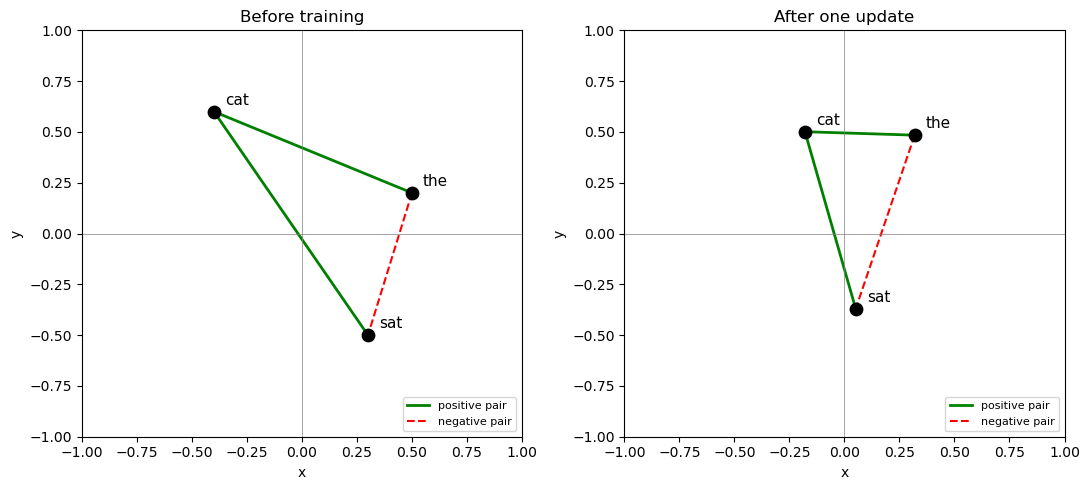

In [7]:
import matplotlib.pyplot as plt

positive_pairs = [("the", "cat"), ("cat", "sat")]
negative_pairs = [("the", "sat")]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, coords, title in [(axes[0], before, "Before training"), (axes[1], after, "After one update")]:
    for a, b in positive_pairs:
        ax.plot([coords[a][0], coords[b][0]], [coords[a][1], coords[b][1]],
                color="green", linewidth=2, zorder=1, label="positive pair" if a == "the" else None)
    for a, b in negative_pairs:
        ax.plot([coords[a][0], coords[b][0]], [coords[a][1], coords[b][1]],
                color="red", linewidth=1.5, linestyle="--", zorder=1, label="negative pair")
    for w, v in coords.items():
        ax.scatter(*v, s=80, color="black", zorder=2)
        ax.annotate(w, v, textcoords="offset points", xytext=(8, 5), fontsize=11)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

That's the entire algorithm, made completely transparent: dot product measures current closeness, sigmoid turns it into a confidence, the error tells you which direction is wrong, and the update rule physically moves the point. Everything from here on is this same five-step process, just repeated for every word pair in a real corpus, thousands of times, with PyTorch doing the bookkeeping.

## 6. The same idea, implemented in PyTorch

You just did one update step by hand for 3 words. A real vocabulary has thousands of words and millions of pairs, doing this by hand isn't an option. PyTorch's `nn.Embedding` and `autograd` automate exactly the steps you just did, dot product, sigmoid, error, gradient, update, for every pair, every epoch. The architecture is intentionally simple:

- Two embedding tables: one for a word acting as the **center**, one for a word acting as **context**. (Real implementations often tie or discard one after training; we keep both to make the roles explicit.)
- For a (center, context) pair, look up both vectors and take their dot product. A high dot product means "the model thinks these co-occur."
- Feed that dot product through a sigmoid and compare to the label (1 for real pairs, 0 for negative samples) with binary cross-entropy, same loss function we used in Week 1 for our neuron-from-scratch example.

We'll keep "cat" and "sat" from the above example, but now embed them in a small corpus, cats and dogs sitting, running, and sleeping in a few places, repeated enough times that real patterns can form. A single sentence like "the cat sat" has no repetition to learn from; a corpus needs it.

In [8]:
import random
import torch
import torch.nn as nn

torch.manual_seed(0)
random.seed(0)

base_corpus = [
    "the cat sat on the mat",
    "the dog sat on the rug",
    "the cat ran in the yard",
    "the dog ran in the park",
    "the cat slept on the mat",
    "the dog slept on the rug",
    "a cat and a dog played in the yard",
    "the cat played in the park",
    "the dog sat on the mat",
    "the cat sat on the rug",
]
corpus = base_corpus * 15  # repeat so there's enough signal to learn from

tokenized = [s.split() for s in corpus]
vocab = sorted(set(w for sent in tokenized for w in sent))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")
print(f"Vocabulary: {vocab}")

def make_pairs(tokenized, window=2):
    pairs = []
    for sent in tokenized:
        idxs = [word2idx[w] for w in sent]
        for i, center in enumerate(idxs):
            start, end = max(0, i - window), min(len(idxs), i + window + 1)
            for j in range(start, end):
                if j != i:
                    pairs.append((center, idxs[j]))
    return pairs

pairs = make_pairs(tokenized, window=2)
print(f"Total positive training pairs: {len(pairs)}")

ModuleNotFoundError: No module named 'torch'

In [ ]:
class SkipGramNegSampling(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.center_embed = nn.Embedding(vocab_size, embed_dim)
        self.context_embed = nn.Embedding(vocab_size, embed_dim)

    def forward(self, center_idx, context_idx):
        c = self.center_embed(center_idx)      # (batch, embed_dim)
        o = self.context_embed(context_idx)    # (batch, embed_dim)
        return (c * o).sum(dim=-1)              # dot product -> raw logit

def get_negative_samples(vocab_size, exclude_idx, k):
    negatives = []
    while len(negatives) < k:
        n = random.randrange(vocab_size)
        if n != exclude_idx:
            negatives.append(n)
    return negatives

In [ ]:
embed_dim = 16
k_negatives = 4
epochs = 150

model = SkipGramNegSampling(vocab_size, embed_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss()

for epoch in range(epochs):
    random.shuffle(pairs)
    total_loss = 0.0
    for center, context in pairs:
        negatives = get_negative_samples(vocab_size, context, k_negatives)
        centers = torch.tensor([center] * (1 + k_negatives))
        contexts = torch.tensor([context] + negatives)
        labels = torch.tensor([1.0] + [0.0] * k_negatives)

        logits = model(centers, contexts)
        loss = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch % 30 == 0:
        print(f"epoch {epoch:4d}  avg loss {total_loss / len(pairs):.4f}")

Loss should drop sharply in the first few epochs, then level off, same shape you saw with the Week 1 hand-worked example. Now let's pull the learned embeddings out and see if they captured anything sensible.

In [ ]:
import numpy as np

embeddings = model.center_embed.weight.detach().numpy()

def nearest_neighbors(word, k=5):
    idx = word2idx[word]
    v = embeddings[idx]
    sims = embeddings @ v / (np.linalg.norm(embeddings, axis=1) * np.linalg.norm(v) + 1e-9)
    order = np.argsort(-sims)
    return [(idx2word[i], round(float(sims[i]), 3)) for i in order if i != idx][:k]

for word in ["cat", "dog", "sat", "mat", "yard"]:
    print(f"Nearest to {word!r}: {nearest_neighbors(word)}")

Now the payoff. Look at the neighbors: "cat" and "dog" should end up near each other, "sat" and "slept" near each other, "mat" and "rug" near each other. None of that was programmed in, it fell out purely from these words appearing in matching sentence positions across the corpus. Compare this to the hand-calc example: same five-step update, just applied automatically to thousands of pairs instead of 3. Let's visualize what the model learned.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

plt.figure(figsize=(9, 7))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.6)
for i, word in idx2word.items():
    plt.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=9)
plt.title("Word2Vec embeddings projected to 2D (PCA)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.tight_layout()
plt.show()

## 7. Word2Vec at scale with `gensim`

Implementing the algorithm by hand is how you learn what's actually happening. In practice, nobody retrains Word2Vec from scratch, they use a mature library. `gensim`'s `Word2Vec` implements the same skip-gram-with-negative-sampling algorithm we just built, but optimized in C and trained on however much data you give it.

Let's train on a slightly larger, more repetitive toy corpus so the semantic clustering is actually visible.

In [ ]:
from gensim.models import Word2Vec

sentences = [
    "the king ruled the kingdom with wisdom".split(),
    "the queen ruled the kingdom with grace".split(),
    "the king and queen lived in the castle".split(),
    "the prince will become king one day".split(),
    "the princess will become queen one day".split(),
    "the man walked into the room".split(),
    "the woman walked into the room".split(),
    "the man and woman greeted the king".split(),
    "the dog ran across the yard".split(),
    "the cat ran across the yard".split(),
    "the dog and cat slept by the fire".split(),
] * 20  # repeat so gensim has enough signal to converge

w2v = Word2Vec(sentences, vector_size=32, window=3, negative=5, min_count=1, sg=1, epochs=50, seed=0)

print(w2v.wv.most_similar("king", topn=5))
print(w2v.wv.most_similar("queen", topn=5))
print(w2v.wv.most_similar("dog", topn=5))

Even with this toy corpus, `king` and `queen` should end up near royalty-related words, and `dog`/`cat` near each other, because they appear in matching sentence patterns. This is the same phenomenon behind the famous `king - man + woman ≈ queen` result from the original Word2Vec paper: directions in embedding space end up encoding relationships, not just similarity. With a real corpus (billions of words) that structure gets far richer.

## 8. Where this goes next

Word2Vec embeddings are **static**: the word `bank` gets exactly one vector, whether you mean a riverbank or a financial institution. That's a real limitation, and it's precisely the problem Transformer architectures were built to solve, by making embeddings **contextual**, changing based on the surrounding words. That's where Week 3 (Looking Inside LLMs) picks up.

## 9. Exercise: embeddings for recommendation systems

Word2Vec doesn't care what a "word" or a "sentence" actually is. It only cares about co-occurrence patterns in sequences. So if you replace words with songs and sentences with playlists, the exact same algorithm learns which songs tend to show up together, and that gives you a recommendation engine, with no labeled ratings data at all.

The cell below handles data loading for you: it tries to pull a real public playlist dataset, and falls back to a synthetic, genre-clustered playlist dataset if that URL isn't reachable on your network. Either way, `playlists` ends up as a list of playlists, where each playlist is a list of song IDs, and `songs_df` maps song IDs to titles and artists.

**Your task:**

1. Train a `gensim` `Word2Vec` model on `playlists`, treating each playlist as a "sentence" and each song ID as a "word." (Use skip-gram, `sg=1`.)
2. Write a `recommend(song_id, topn=5)` function that returns the `topn` most similar songs to a given song, using `model.wv.most_similar`.
3. Pick 2-3 seed songs and print their recommendations. If you're on the real dataset, sanity-check the results against songs or artists you recognize. If you're on the synthetic fallback, check whether recommendations stay within the same made-up genre.
4. In a markdown cell, answer: this approach recommends songs with zero labeled ratings data, no one told the model "these songs are similar." What in the training data is actually doing the work of defining similarity here? Would this approach work well for a song that only appears in one playlist? Why or why not?


In [ ]:
import random
from urllib import request
import pandas as pd
from gensim.models import Word2Vec

random.seed(0)

try:
    data = request.urlopen(
        "https://storage.googleapis.com/maps-premium/dataset/yes_complete/train.txt", timeout=5
    )
    lines = data.read().decode("utf-8").split("\n")[2:]
    playlists = [s.rstrip().split() for s in lines if len(s.split()) > 1]

    songs_file = request.urlopen(
        "https://storage.googleapis.com/maps-premium/dataset/yes_complete/song_hash.txt", timeout=5
    )
    songs_lines = songs_file.read().decode("utf-8").split("\n")
    songs = [s.rstrip().split("\t") for s in songs_lines if s.strip()]
    songs_df = pd.DataFrame(data=songs, columns=["id", "title", "artist"]).set_index("id")

    print(f"Loaded real dataset: {len(playlists):,} playlists, {len(songs_df):,} songs")
    using_real_data = True

except Exception as e:
    print(f"Could not reach the real dataset ({e}). Using a synthetic playlist dataset instead.\n")

    genres = {
        "rock": [f"rock_{i}" for i in range(8)],
        "pop": [f"pop_{i}" for i in range(8)],
        "jazz": [f"jazz_{i}" for i in range(8)],
        "classical": [f"classical_{i}" for i in range(8)],
    }
    all_songs = [s for group in genres.values() for s in group]
    songs_df = pd.DataFrame({
        "id": all_songs,
        "title": [s.replace("_", " ").title() for s in all_songs],
        "artist": [f"Artist {s.split('_')[1]}" for s in all_songs],
    }).set_index("id")

    playlists = []
    for _ in range(2000):
        genre_songs = random.choice(list(genres.values()))
        length = random.randint(6, 15)
        playlists.append(random.choices(genre_songs, k=length))

    print(f"Generated {len(playlists):,} synthetic playlists across {len(genres)} genres")
    using_real_data = False

In [ ]:
# TODO: 1. Train a gensim Word2Vec model on `playlists` (sg=1)
# Tip: if using_real_data, larger window/negative/vector_size and fewer epochs
# work well (e.g. window=20, negative=50, epochs=10). If using the synthetic
# fallback, a smaller window and more epochs converges better
# (e.g. window=8, negative=10, epochs=20).


# TODO: 2. Write recommend(song_id, topn=5) using model.wv.most_similar


# TODO: 3. Print recommendations for 2-3 seed songs
